In [6]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from scratch import *
import scratch

importlib.reload(scratch)

<module 'scratch' from '/Users/debashisgupta/Desktop/Course/K-UTD/Fall-26/DL/K-Project1/Code/scratch.py'>

In [7]:
print("\nLoading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprossing data...")

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)



Loading MNIST data...
Preprossing data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


In [8]:
DEPTH_OUTPUT_DIR = Path("output/depth_same_neurons")
DEPTH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPTH_ARCHITECTURES = {
    "1_hidden_layer": [128],
    "2_hidden_layers": [128, 128],
    "3_hidden_layers": [128, 128, 128]
}
DEPTH_ACTIVATION = "relu"
DEPTH_INITIALIZATION = "small"
DEPTH_LEARNING_RATE = 0.1
DEPTH_BATCH_SIZE = 128

DEPTH_EPOCHS = 100

DEPTH_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)


print("Depth experiment output:", DEPTH_OUTPUT_DIR)
print("Architectures:", DEPTH_ARCHITECTURES)
print("Activation:", DEPTH_ACTIVATION)
print("Initialization:", DEPTH_INITIALIZATION)
print("Learning rate:", DEPTH_LEARNING_RATE)
print("Batch size:", DEPTH_BATCH_SIZE)
print("Epochs:", DEPTH_EPOCHS)
print("Seeds:", DEPTH_SEEDS)

Depth experiment output: output/depth_same_neurons
Architectures: {'1_hidden_layer': [128], '2_hidden_layers': [128, 128], '3_hidden_layers': [128, 128, 128]}
Activation: relu
Initialization: small
Learning rate: 0.1
Batch size: 128
Epochs: 100
Seeds: [654571, 89250, 773955]


In [9]:
def depth_initialize_parameters(input_size, hidden_sizes, output_size, initialization="he",seed=SPLIT_SEED):
    rng = np.random.default_rng(seed)
    
    layers_sizes = ([input_size] + list(hidden_sizes) + [output_size])
    parameters = {}
    number_of_weight_layers = len(layers_sizes) - 1
    
    for layer_number in range(1, number_of_weight_layers +1):
        inp = layers_sizes[layer_number - 1]
        out = layers_sizes[layer_number]
        
        if initialization == "he":
            scale = np.sqrt(2.0 / inp)
        elif initialization == "xavier":
            scale = np.sqrt(1.0 / inp)
        elif initialization =="small":
            scale = 0.01
        elif initialization == "large":
            scale = 1.0
        elif initialization == "zero":
            scale = 0.0
        else:
            raise ValueError(f"Unknown initialization method: {initialization}")
        
        parameters[f"W{layer_number}"] = (rng.standard_normal(size=(inp, out)) * scale).astype(np.float64)
        parameters[f"b{layer_number}"] = np.zeros((1, out), dtype=np.float64)
    return parameters

def depth_forward_pass(X, parameters, activation="relu"):
    number_of_weigh_layers = len(parameters) // 2
    number_of_hidden_layers = number_of_weigh_layers - 1
    
    cache = {"A0":X}
    A_previous = X
    # hidden layers conclusion
    for layer_number in range(1, number_of_hidden_layers + 1):
        W = parameters[f"W{layer_number}"]
        b = parameters[f"b{layer_number}"]
        Z = np.dot(A_previous, W) + b
        A = activation_forward(Z, activation)
        cache[f"Z{layer_number}"] = Z
        cache[f"A{layer_number}"] = A
        A_previous = A
    
    ## at output layer 
    output_layer_number = number_of_weigh_layers
    W_output = parameters[f"W{output_layer_number}"]
    b_output = parameters[f"b{output_layer_number}"]
    
    logits = (np.dot(A_previous,W_output) + b_output)
    probailities = softmax(logits)
    cache["logits"] = logits
    cache["probabilities"] = probailities
    return probailities, cache

## backpropagation

def depth_backward_pass(y,parameters, cache, activation="relu"):
    gradients = {}
    number_of_weigh_layers = len(parameters) // 2
    number_of_hidden_layers = number_of_weigh_layers - 1
    probabilities = cache["probabilities"]
    batch_size = y.shape[0]
    
    # softmax cross entropy
    dlogits = probabilities.copy()
    
    dlogits[np.arange(batch_size), y] -= 1.0
    dlogits /= batch_size
    
    output_layer_number = number_of_weigh_layers
    A_previous = cache[f"A{number_of_hidden_layers}"]
    gradients[f"dW{output_layer_number}"] = np.dot(A_previous.T, dlogits)
    gradients[f"db{output_layer_number}"] = np.sum(dlogits, axis=0, keepdims=True)
    
    dA = np.dot(dlogits, parameters[f"W{output_layer_number}"].T)
    
    #hidden layer calcuations
    for layer_number in range(number_of_hidden_layers,0,-1):
        Z = cache[f"Z{layer_number}"]
        dZ = (dA * activation_derivative(Z, activation))
        A_previous = cache[f"A{layer_number - 1}"]
        gradients[f"dW{layer_number}"] = np.dot(A_previous.T, dZ)
        gradients[f"db{layer_number}"] = np.sum(dZ, axis=0, keepdims=True)
        if layer_number > 1:
            dA = np.dot(dZ, parameters[f"W{layer_number}"].T)
            
    return gradients

## updating the params
def depth_update_parameters(parameters, gradients, learning_rate):
    number_of_weigh_layers = len(parameters) // 2
    
    for layer_number in range(1, number_of_weigh_layers + 1):
        parameters[f"W{layer_number}"] -= learning_rate * gradients[f"dW{layer_number}"]
        parameters[f"b{layer_number}"] -= learning_rate * gradients[f"db{layer_number}"]
    
    return parameters

## evaluating model
def depth_evaluate_model(X, y, parameters, activation="relu",evaluation_batch_size=128):
    num_samples = X.shape[0]
    num_batches = int(np.ceil(num_samples / evaluation_batch_size))
    
    total_loss = 0.0
    total_correct = 0
    total_examples = X.shape[0]
    
    for start in range(0, total_examples, evaluation_batch_size):
        end = min(start + evaluation_batch_size, total_examples)
        X_batch = X[start:end]
        y_batch = y[start:end]
        
        probabilities, cache = depth_forward_pass(X_batch, parameters, activation)
        batch_loss = cross_entropy_loss(cache['logits'], y_batch)
        predictions = np.argmax(probabilities, axis=1)
        total_loss += (batch_loss * X_batch.shape[0])
        total_correct += np.sum(predictions == y_batch)
    
    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return average_loss, accuracy

## training the model

def depth_train_model(X_train, y_train, X_val, y_val, hidden_sizes, activation="relu", initialization='he',learning_rate=0.1,
                      batch_size=128, epochs=100, seed=SPLIT_SEED, verbose=True):
    rng = np.random.default_rng(seed)
    parameters = depth_initialize_parameters(X_train.shape[1], hidden_sizes, 10, initialization, seed)
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    number_of_examples = X_train.shape[0]
    
    for epoch in range(epochs):
        shuffled_indices = rng.permutation(number_of_examples)
        epoch_loss_sum = 0.0
        epoch_correct_sum = 0
        for start in range(0, number_of_examples, batch_size):
            end = min(start+batch_size, number_of_examples)
            batch_indices = shuffled_indices[start:end]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            probabilities, cache = depth_forward_pass(X_batch, parameters, activation)
            batch_loss = cross_entropy_loss(cache['logits'], y_batch)
            if not np.isfinite(batch_loss):
                raise FloatingPointError(f"Non finite loss found at epoch {epoch+1}")

            epoch_loss_sum += (batch_loss * X_batch.shape[0])
            predictions = np.argmax(probabilities, axis=1)
            epoch_correct_sum += np.sum(predictions == y_batch)
            gradients = depth_backward_pass(y_batch, parameters, cache, activation)
            gradients_are_finite = all(np.isfinite(grad).all() for grad in gradients.values())
            if not gradients_are_finite:
                raise FloatingPointError(f"Non finite gradients found at epoch {epoch+1}")
            parameters = depth_update_parameters(parameters, gradients, learning_rate)
            
        train_loss = epoch_loss_sum / number_of_examples
        train_accuracy = epoch_correct_sum / number_of_examples
        val_loss, val_accuracy = depth_evaluate_model(X_val, y_val, parameters, activation)
        
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        
        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
        if epoch+1 == epochs:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
            
    return parameters, history
    
#total parameters count
def depth_count_parameters(parameters):
    return sum(parameter.size for parameter in parameters.values())
    

In [10]:
depth_results = {}
depth_final_rows = []
depth_history_rows = []

total_runs = (
    len(DEPTH_ARCHITECTURES)
    * len(DEPTH_SEEDS)
)

run_number = 0


for architecture_name, hidden_sizes in (
    DEPTH_ARCHITECTURES.items()
):
    print("\n" + "=" * 75)
    print("Architecture:", architecture_name)
    print("Hidden sizes:", hidden_sizes)
    print("=" * 75)

    architecture_histories = []
    architecture_models = {}

    for seed in DEPTH_SEEDS:
        run_number += 1

        print(
            f"\nRun {run_number}/{total_runs} | "
            f"architecture={architecture_name} | "
            f"seed={seed}"
        )

        start_time = time.perf_counter()

        parameters, history = depth_train_model(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            hidden_sizes=hidden_sizes,
            activation=DEPTH_ACTIVATION,
            initialization=DEPTH_INITIALIZATION,
            learning_rate=DEPTH_LEARNING_RATE,
            batch_size=DEPTH_BATCH_SIZE,
            epochs=DEPTH_EPOCHS,
            seed=seed,
            verbose=True
        )

        elapsed_seconds = (
            time.perf_counter() - start_time
        )

        final_train_loss, final_train_accuracy = (
            depth_evaluate_model(
                X_train,
                y_train,
                parameters,
                DEPTH_ACTIVATION
            )
        )

        final_val_loss, final_val_accuracy = (
            depth_evaluate_model(
                X_val,
                y_val,
                parameters,
                DEPTH_ACTIVATION
            )
        )

        parameter_count = depth_count_parameters(
            parameters
        )

        generalization_gap = (
            final_train_accuracy
            - final_val_accuracy
        )

        architecture_histories.append(history)
        architecture_models[seed] = parameters

        for epoch_index in range(
            len(history["train_loss"])
        ):
            depth_history_rows.append({
                "architecture": architecture_name,
                "hidden_sizes": str(hidden_sizes),
                "number_of_hidden_layers": len(
                    hidden_sizes
                ),
                "seed": seed,
                "epoch": epoch_index + 1,
                "train_loss": history[
                    "train_loss"
                ][epoch_index],
                "train_accuracy": history[
                    "train_accuracy"
                ][epoch_index],
                "val_loss": history[
                    "val_loss"
                ][epoch_index],
                "val_accuracy": history[
                    "val_accuracy"
                ][epoch_index]
            })

        depth_final_rows.append({
            "architecture": architecture_name,
            "hidden_sizes": str(hidden_sizes),
            "number_of_hidden_layers": len(
                hidden_sizes
            ),
            "seed": seed,
            "parameter_count": parameter_count,
            "final_train_loss": final_train_loss,
            "final_train_accuracy": (
                final_train_accuracy
            ),
            "final_val_loss": final_val_loss,
            "final_val_accuracy": (
                final_val_accuracy
            ),
            "generalization_gap": (
                generalization_gap
            ),
            "training_seconds": elapsed_seconds
        })

        print(
            f"Completed | "
            f"parameters={parameter_count:,} | "
            f"train accuracy="
            f"{100 * final_train_accuracy:.2f}% | "
            f"validation accuracy="
            f"{100 * final_val_accuracy:.2f}% | "
            f"gap="
            f"{100 * generalization_gap:.2f} points | "
            f"time={elapsed_seconds:.1f} seconds"
        )

    depth_results[architecture_name] = {
        "hidden_sizes": hidden_sizes,
        "models": architecture_models,
        "histories": architecture_histories
    }





Architecture: 1_hidden_layer
Hidden sizes: [128]

Run 1/9 | architecture=1_hidden_layer | seed=654571
Epoch 1/100: Train Loss: 0.8556, Train Accuracy: 0.7721, Val Loss: 0.3852, Val Accuracy: 0.8895
Epoch 11/100: Train Loss: 0.1242, Train Accuracy: 0.9659, Val Loss: 0.1362, Val Accuracy: 0.9612
Epoch 21/100: Train Loss: 0.0673, Train Accuracy: 0.9820, Val Loss: 0.0939, Val Accuracy: 0.9719
Epoch 31/100: Train Loss: 0.0423, Train Accuracy: 0.9893, Val Loss: 0.0815, Val Accuracy: 0.9759
Epoch 41/100: Train Loss: 0.0282, Train Accuracy: 0.9939, Val Loss: 0.0764, Val Accuracy: 0.9775
Epoch 51/100: Train Loss: 0.0198, Train Accuracy: 0.9968, Val Loss: 0.0758, Val Accuracy: 0.9782
Epoch 61/100: Train Loss: 0.0142, Train Accuracy: 0.9984, Val Loss: 0.0761, Val Accuracy: 0.9783
Epoch 71/100: Train Loss: 0.0105, Train Accuracy: 0.9990, Val Loss: 0.0768, Val Accuracy: 0.9776
Epoch 81/100: Train Loss: 0.0082, Train Accuracy: 0.9994, Val Loss: 0.0774, Val Accuracy: 0.9779
Epoch 91/100: Train Loss:


DEPTH EXPERIMENT: FINAL MEAN ± SAMPLE STANDARD DEVIATION


,Hidden Layers,Parameters,Train Accuracy,Validation Accuracy,Validation Loss,Generalization Gap,Training Time
0,1,"101,770",99.99% ± 0.01%,97.81% ± 0.05%,0.0808 ± 0.0016,2.18 ± 0.06 points,24.9 ± 1.2 sec
1,2,"118,282",100.00% ± 0.00%,97.89% ± 0.14%,0.1071 ± 0.0037,2.11 ± 0.14 points,36.2 ± 1.7 sec
2,3,"134,794",100.00% ± 0.00%,97.24% ± 0.15%,0.1825 ± 0.0082,2.76 ± 0.15 points,41.0 ± 3.7 sec


Saved: output/depth_same_neurons/depth_comparison_curves.png


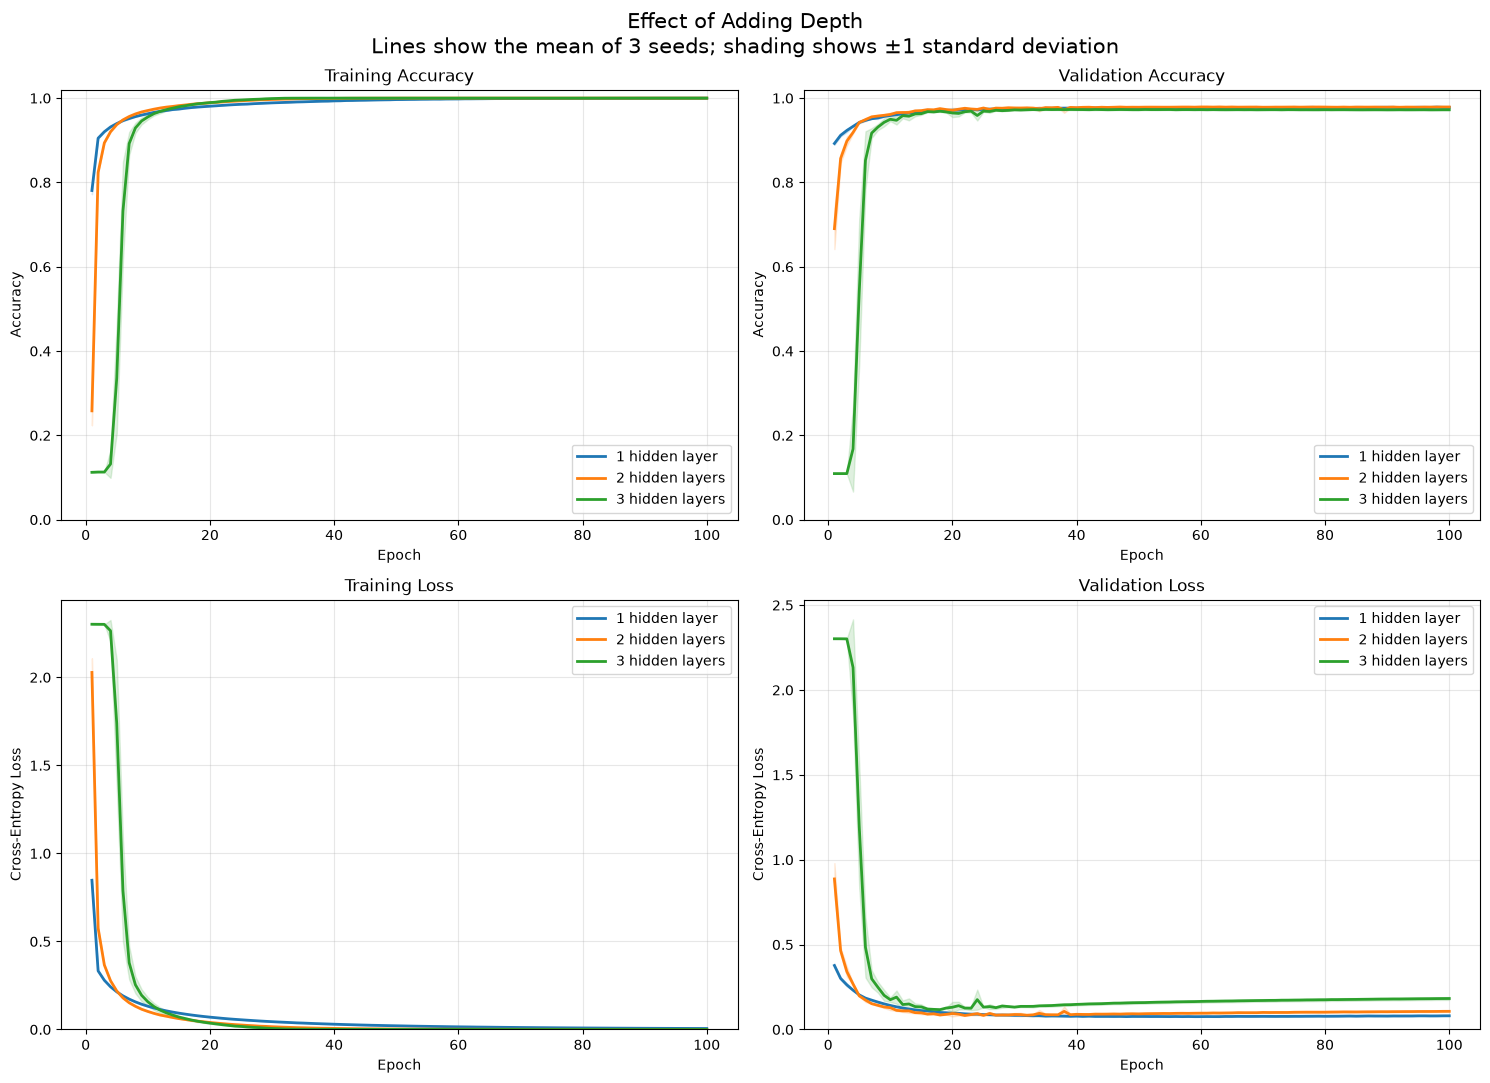


Saved files:
- output/depth_same_neurons/depth_all_histories.csv
- output/depth_same_neurons/depth_comparison_curves.png
- output/depth_same_neurons/depth_epoch_mean_std.csv
- output/depth_same_neurons/depth_results_by_seed.csv
- output/depth_same_neurons/depth_summary_formatted.csv
- output/depth_same_neurons/depth_summary_numeric.csv


In [11]:


depth_final_df = pd.DataFrame(
    depth_final_rows
)

depth_history_df = pd.DataFrame(
    depth_history_rows
)


depth_summary_df = (
    depth_final_df
    .groupby(
        [
            "architecture",
            "number_of_hidden_layers",
            "parameter_count"
        ],
        as_index=False
    )
    .agg(
        train_loss_mean=(
            "final_train_loss",
            "mean"
        ),
        train_loss_std=(
            "final_train_loss",
            "std"
        ),
        train_accuracy_mean=(
            "final_train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "final_train_accuracy",
            "std"
        ),
        val_loss_mean=(
            "final_val_loss",
            "mean"
        ),
        val_loss_std=(
            "final_val_loss",
            "std"
        ),
        val_accuracy_mean=(
            "final_val_accuracy",
            "mean"
        ),
        val_accuracy_std=(
            "final_val_accuracy",
            "std"
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean"
        ),
        generalization_gap_std=(
            "generalization_gap",
            "std"
        ),
        training_seconds_mean=(
            "training_seconds",
            "mean"
        ),
        training_seconds_std=(
            "training_seconds",
            "std"
        )
    )
    .sort_values("number_of_hidden_layers")
)


depth_display_rows = []

for _, row in depth_summary_df.iterrows():
    depth_display_rows.append({
        "Hidden Layers": int(
            row["number_of_hidden_layers"]
        ),
        "Parameters": f"{int(row['parameter_count']):,}",
        "Train Accuracy": (
            f"{100 * row['train_accuracy_mean']:.2f}% "
            f"± {100 * row['train_accuracy_std']:.2f}%"
        ),
        "Validation Accuracy": (
            f"{100 * row['val_accuracy_mean']:.2f}% "
            f"± {100 * row['val_accuracy_std']:.2f}%"
        ),
        "Validation Loss": (
            f"{row['val_loss_mean']:.4f} "
            f"± {row['val_loss_std']:.4f}"
        ),
        "Generalization Gap": (
            f"{100 * row['generalization_gap_mean']:.2f} "
            f"± "
            f"{100 * row['generalization_gap_std']:.2f} "
            "points"
        ),
        "Training Time": (
            f"{row['training_seconds_mean']:.1f} "
            f"± {row['training_seconds_std']:.1f} sec"
        )
    })


depth_display_df = pd.DataFrame(
    depth_display_rows
)

print("\n" + "=" * 100)
print("DEPTH EXPERIMENT: FINAL MEAN ± SAMPLE STANDARD DEVIATION")
print("=" * 100)

display(depth_display_df)


# ============================================================
# 11. Calculate mean ± SD at every epoch
# ============================================================

depth_epoch_summary_df = (
    depth_history_df
    .groupby(
        ["architecture", "epoch"],
        as_index=False
    )
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        train_accuracy_mean=(
            "train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "train_accuracy",
            "std"
        ),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
        val_accuracy_mean=(
            "val_accuracy",
            "mean"
        ),
        val_accuracy_std=(
            "val_accuracy",
            "std"
        )
    )
)


# ============================================================
# 12. Plot the depth comparison
# ============================================================

depth_colors = {
    "1_hidden_layer": "tab:blue",
    "2_hidden_layers": "tab:orange",
    "3_hidden_layers": "tab:green"
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)


for architecture_name in DEPTH_ARCHITECTURES:
    architecture_data = (
        depth_epoch_summary_df[
            depth_epoch_summary_df[
                "architecture"
            ] == architecture_name
        ]
        .sort_values("epoch")
    )

    epochs = architecture_data[
        "epoch"
    ].to_numpy()

    color = depth_colors[
        architecture_name
    ]

    label = architecture_name.replace(
        "_",
        " "
    )

    plot_information = [
        (
            axes[0, 0],
            "train_accuracy_mean",
            "train_accuracy_std"
        ),
        (
            axes[0, 1],
            "val_accuracy_mean",
            "val_accuracy_std"
        ),
        (
            axes[1, 0],
            "train_loss_mean",
            "train_loss_std"
        ),
        (
            axes[1, 1],
            "val_loss_mean",
            "val_loss_std"
        )
    ]

    for axis, mean_column, std_column in (
        plot_information
    ):
        mean_values = architecture_data[
            mean_column
        ].to_numpy()

        std_values = architecture_data[
            std_column
        ].to_numpy()

        axis.plot(
            epochs,
            mean_values,
            color=color,
            linewidth=2,
            label=label
        )

        if "accuracy" in mean_column:
            lower_values = np.clip(
                mean_values - std_values,
                0,
                1
            )

            upper_values = np.clip(
                mean_values + std_values,
                0,
                1
            )

        else:
            lower_values = np.maximum(
                mean_values - std_values,
                0
            )

            upper_values = (
                mean_values + std_values
            )

        axis.fill_between(
            epochs,
            lower_values,
            upper_values,
            color=color,
            alpha=0.15
        )


axes[0, 0].set_title("Training Accuracy")
axes[0, 1].set_title("Validation Accuracy")
axes[1, 0].set_title("Training Loss")
axes[1, 1].set_title("Validation Loss")

for axis in axes.flat:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)
    axis.legend()

axes[0, 0].set_ylabel("Accuracy")
axes[0, 1].set_ylabel("Accuracy")
axes[1, 0].set_ylabel("Cross-Entropy Loss")
axes[1, 1].set_ylabel("Cross-Entropy Loss")

axes[0, 0].set_ylim(0, 1.02)
axes[0, 1].set_ylim(0, 1.02)
axes[1, 0].set_ylim(bottom=0)
axes[1, 1].set_ylim(bottom=0)

fig.suptitle(
    "Effect of Adding Depth\n"
    "Lines show the mean of 3 seeds; "
    "shading shows ±1 standard deviation",
    fontsize=15
)

plt.tight_layout()

depth_figure_path = (
    DEPTH_OUTPUT_DIR
    / "depth_comparison_curves.png"
)

fig.savefig(
    depth_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", depth_figure_path)

plt.show()
plt.close(fig)


# ============================================================
# 13. Save numerical results
# ============================================================

depth_final_df.to_csv(
    DEPTH_OUTPUT_DIR
    / "depth_results_by_seed.csv",
    index=False
)

depth_history_df.to_csv(
    DEPTH_OUTPUT_DIR
    / "depth_all_histories.csv",
    index=False
)

depth_epoch_summary_df.to_csv(
    DEPTH_OUTPUT_DIR
    / "depth_epoch_mean_std.csv",
    index=False
)

depth_summary_df.to_csv(
    DEPTH_OUTPUT_DIR
    / "depth_summary_numeric.csv",
    index=False
)

depth_display_df.to_csv(
    DEPTH_OUTPUT_DIR
    / "depth_summary_formatted.csv",
    index=False
)

print("\nSaved files:")

for saved_file in sorted(
    DEPTH_OUTPUT_DIR.iterdir()
):
    print("-", saved_file)